# Phishing URL Classification with Gaussian Naive Bayes

**Goal:** Build an end-to-end, leakage-safe machine-learning pipeline for phishing URL classification using the requested **GaussianNB** algorithm.

### Workflow
1. Load and audit the dataset
2. Clean and validate data
3. Analyze target balance and feature distributions
4. Remove non-model fields and constant predictors
5. Perform stratified train/test split
6. Build a preprocessing + GaussianNB pipeline
7. Tune `var_smoothing` with 5-fold cross-validation
8. Evaluate with accuracy, precision, recall, F1 and ROC-AUC
9. Plot confusion matrix, ROC and precision-recall curves
10. Estimate permutation feature importance
11. Demonstrate validation-based threshold tuning for a security-oriented operating point
12. Save the trained model


In [33]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("dataset_phishing.csv")

print("Looking for dataset at:", DATA_PATH.resolve())
print("Dataset exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:", len(df.columns))
print("\nData types:")
print(df.dtypes.value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

print("\nTarget distribution:")
print(df["status"].value_counts())

print("\nTarget proportion:")
print(df["status"].value_counts(normalize=True))

Looking for dataset at: E:\Ml_Training\PBL2\Phising-Classifier-FULL-PROJECT\tranning_data\dataset_phishing.csv
Dataset exists: True
Shape: (11430, 89)

Columns: 89

Data types:
int64      74
float64    13
str         2
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0

Target distribution:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Target proportion:
status
legitimate    0.5
phishing      0.5
Name: proportion, dtype: float64


In [34]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42

from pathlib import Path

DATA_PATH = Path("dataset_phishing.csv")

print("Looking for dataset at:", DATA_PATH.resolve())
print("Dataset exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)


Looking for dataset at: E:\Ml_Training\PBL2\Phising-Classifier-FULL-PROJECT\tranning_data\dataset_phishing.csv
Dataset exists: True


In [35]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:", len(df.columns))
print("\nData types:")
print(df.dtypes.value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("\nTarget distribution:")
print(df["status"].value_counts())
print("\nTarget proportion:")
print(df["status"].value_counts(normalize=True))


Shape: (11430, 89)

Columns: 89

Data types:
int64      74
float64    13
str         2
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0

Target distribution:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Target proportion:
status
legitimate    0.5
phishing      0.5
Name: proportion, dtype: float64


In [36]:
# Full feature audit
audit = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True)
}).sort_values(["missing", "unique"])

display(audit)

constant_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if df[c].nunique(dropna=False) <= 1
]
print("\nConstant numeric columns:", constant_cols)


,dtype,missing,unique,min,max
nb_or,int64,0,1,0.0,0.0
ratio_intErrors,int64,0,1,0.0,0.0
ratio_intRedirection,int64,0,1,0.0,0.0
ratio_nullHyperlinks,int64,0,1,0.0,0.0
sfh,int64,0,1,0.0,0.0
...,...,...,...,...,...
ratio_extHyperlinks,float64,0,3131,0.0,1.0
ratio_intHyperlinks,float64,0,3131,0.0,1.0
domain_age,int64,0,4430,-12.0,12874.0
web_traffic,int64,0,4744,0.0,10767986.0



Constant numeric columns: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']


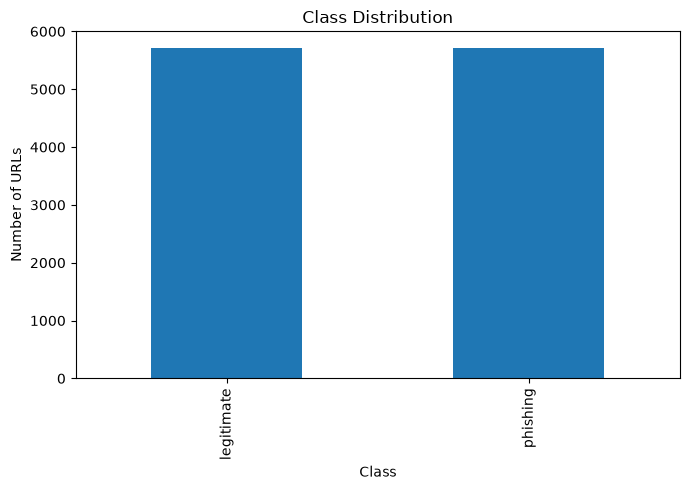

In [37]:
# Class distribution
df["status"].value_counts().reindex(["legitimate", "phishing"]).plot(kind="bar", figsize=(7,5))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of URLs")
plt.tight_layout()
plt.show()


,absolute_correlation
google_index,0.731171
page_rank,0.511137
nb_www,0.443468
ratio_digits_url,0.356395
domain_in_title,0.342807
nb_hyperlinks,0.342628
phish_hints,0.335393
domain_age,0.331889
ip,0.321698
nb_qm,0.294319


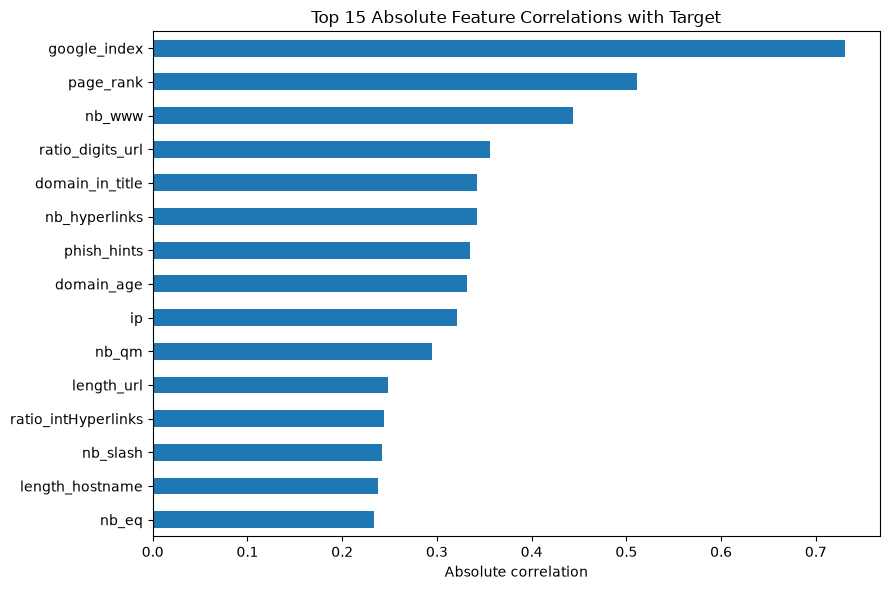

In [38]:
# Target correlation audit
audit_df = df.copy()
audit_df["status"] = audit_df["status"].map({"legitimate": 0, "phishing": 1})

target_corr = (
    audit_df.corr(numeric_only=True)["status"]
    .drop("status")
    .abs()
    .sort_values(ascending=False)
)

display(target_corr.head(20).to_frame("absolute_correlation"))

target_corr.head(15).sort_values().plot(kind="barh", figsize=(9,6))
plt.title("Top 15 Absolute Feature Correlations with Target")
plt.xlabel("Absolute correlation")
plt.tight_layout()
plt.show()


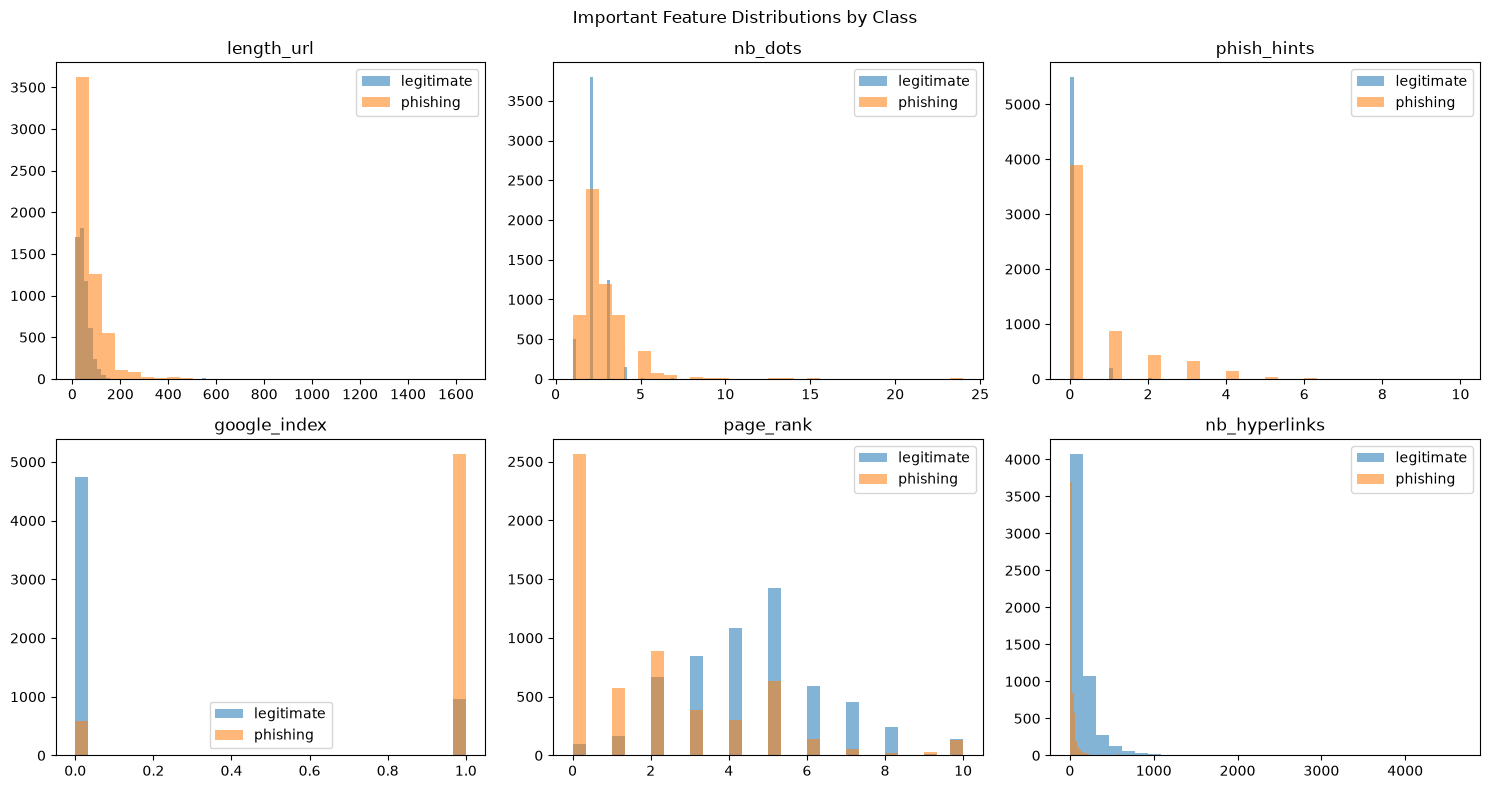

In [39]:
# Key feature distributions
key_features = [
    "length_url", "nb_dots", "phish_hints",
    "google_index", "page_rank", "nb_hyperlinks"
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.ravel(), key_features):
    for label, name in [(0, "legitimate"), (1, "phishing")]:
        ax.hist(audit_df.loc[audit_df["status"] == label, col],
                bins=30, alpha=0.55, label=name)
    ax.set_title(col)
    ax.legend()

fig.suptitle("Important Feature Distributions by Class")
fig.tight_layout()
plt.show()


## Cleaning and feature preparation

- `url` is retained only for traceability and is **not** directly fed into GaussianNB.
- `status` is encoded as `0 = legitimate`, `1 = phishing`.
- Constant predictors are removed because they contain no discriminative information.
- Median imputation is kept inside the pipeline so future missing values are handled without data leakage.
- Standardization is also inside the pipeline.


In [40]:
model_df = df.drop(columns=["url"]).copy()
model_df["status"] = model_df["status"].map({"legitimate": 0, "phishing": 1})

X = model_df.drop(columns=["status"])
y = model_df["status"]

constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
X = X.drop(columns=constant_cols)

print("Features before constant-column removal:", len(model_df.columns) - 1)
print("Constant columns removed:", constant_cols)
print("Final model feature count:", X.shape[1])


Features before constant-column removal: 87
Constant columns removed: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Final model feature count: 81


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve
)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))


Train: (9144, 81)
Test : (2286, 81)

Train class balance:
status
0    0.5
1    0.5
Name: proportion, dtype: float64

Test class balance:
status
1    0.5
0    0.5
Name: proportion, dtype: float64


## GaussianNB pipeline

The pipeline is deliberately leakage-safe:

`Raw features → Median Imputer → StandardScaler → GaussianNB`

`GridSearchCV` tunes the GaussianNB `var_smoothing` hyperparameter using only the training data.


In [43]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

param_grid = {
    "model__var_smoothing": np.logspace(-11, -7, 9)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))


Best parameters: {'model__var_smoothing': np.float64(1e-07)}
Best CV F1: 0.5864


In [44]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
}

display(pd.DataFrame([results]).T.rename(columns={0: "score"}))

print("\nClassification report:")
print(classification_report(
    y_test, y_pred,
    target_names=["legitimate", "phishing"]
))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


,score
accuracy,0.705599
precision,0.938433
recall,0.440070
f1,0.599166
roc_auc,0.927371



Classification report:
              precision    recall  f1-score   support

  legitimate       0.63      0.97      0.77      1143
    phishing       0.94      0.44      0.60      1143

    accuracy                           0.71      2286
   macro avg       0.79      0.71      0.68      2286
weighted avg       0.79      0.71      0.68      2286

Confusion matrix:
[[1110   33]
 [ 640  503]]


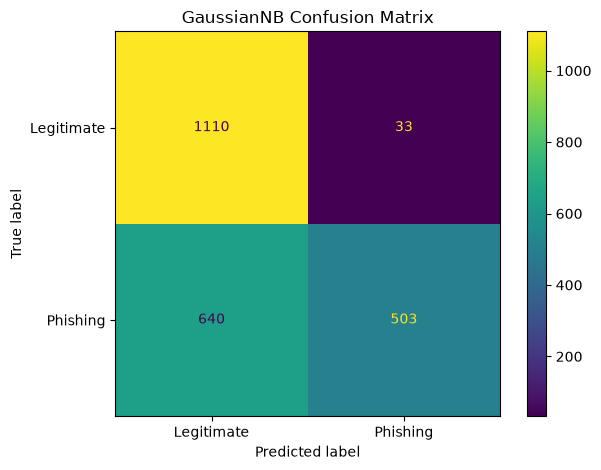

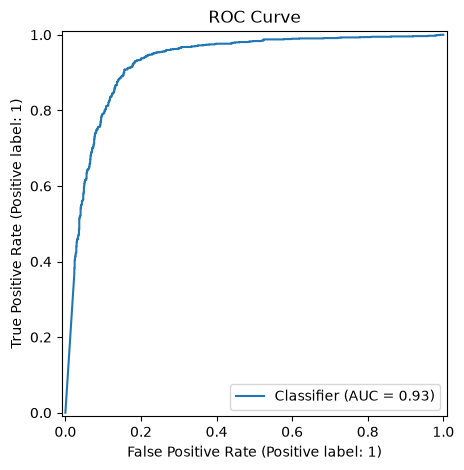

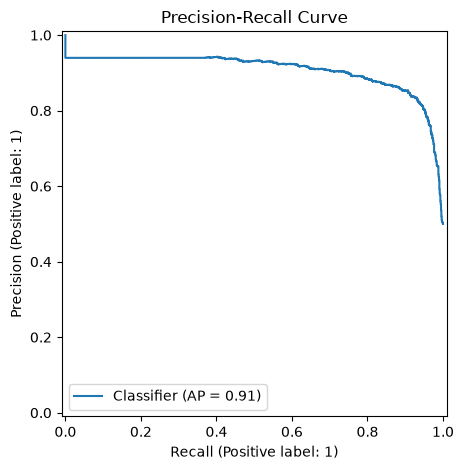

In [45]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Legitimate", "Phishing"]
)
plt.title("GaussianNB Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# Precision-recall
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


,mean_f1_decrease
phish_hints,0.042432
nb_at,0.018727
dns_record,0.015317
suspecious_tld,0.012206
google_index,0.009981
ip,0.007076
nb_slash,0.007054
page_rank,0.006703
nb_hyperlinks,0.006348
ratio_digits_url,0.005093


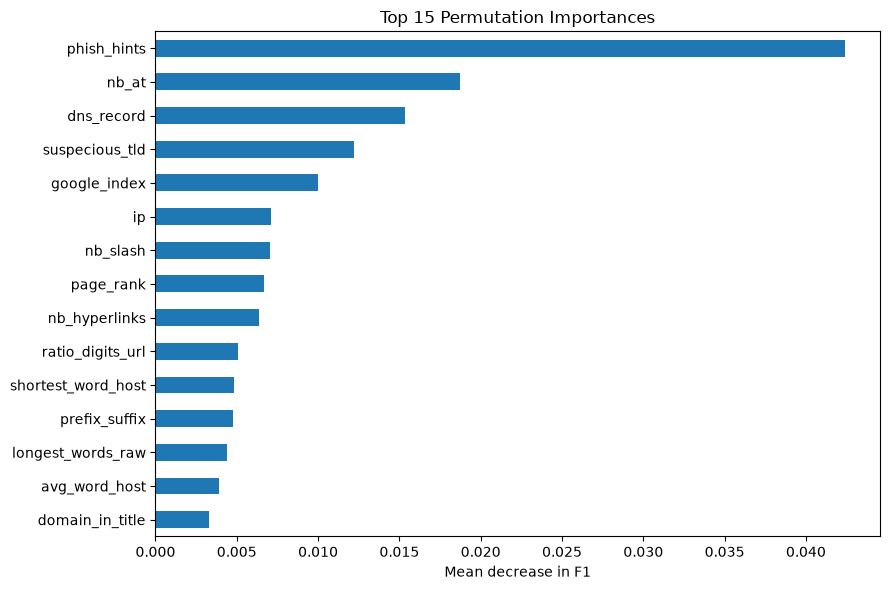

In [46]:
# Permutation importance: model-agnostic feature relevance
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1
)

importance = (
    pd.Series(perm.importances_mean, index=X_test.columns)
    .sort_values(ascending=False)
)

display(importance.head(20).to_frame("mean_f1_decrease"))

importance.head(15).sort_values().plot(kind="barh", figsize=(9,6))
plt.title("Top 15 Permutation Importances")
plt.xlabel("Mean decrease in F1")
plt.tight_layout()
plt.show()


## Security-oriented threshold tuning

For phishing detection, missing a phishing URL can be more costly than flagging an additional legitimate URL. The default GaussianNB decision threshold is `0.5`, but a production system should choose its operating threshold using a validation set and an explicit cost policy.

The following cell tunes the threshold on a validation split only, then evaluates it on a separate final test split.


In [47]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.36, random_state=RANDOM_STATE, stratify=y
)
X_val, X_final_test, y_val, y_final_test = train_test_split(
    X_tmp, y_tmp, test_size=(20/36),
    random_state=RANDOM_STATE, stratify=y_tmp
)

threshold_model = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
threshold_model.fit(X_tr, y_tr)

val_prob = threshold_model.predict_proba(X_val)[:, 1]
p, r, thresholds = precision_recall_curve(y_val, val_prob)
f1s = 2 * p * r / (p + r + 1e-12)
idx = int(np.nanargmax(f1s))
chosen_threshold = float(thresholds[idx]) if idx < len(thresholds) else 0.5

final_prob = threshold_model.predict_proba(X_final_test)[:, 1]
default_pred = (final_prob >= 0.5).astype(int)
tuned_pred = (final_prob >= chosen_threshold).astype(int)

comparison = pd.DataFrame({
    "default_0.5": [
        accuracy_score(y_final_test, default_pred),
        precision_score(y_final_test, default_pred),
        recall_score(y_final_test, default_pred),
        f1_score(y_final_test, default_pred)
    ],
    "validation_tuned": [
        accuracy_score(y_final_test, tuned_pred),
        precision_score(y_final_test, tuned_pred),
        recall_score(y_final_test, tuned_pred),
        f1_score(y_final_test, tuned_pred)
    ]
}, index=["accuracy", "precision", "recall", "f1"])

print("Selected validation threshold:", chosen_threshold)
display(comparison)


Selected validation threshold: 9.037528483483384e-35


,default_0.5,validation_tuned
accuracy,0.699606,0.878443
precision,0.933460,0.845172
recall,0.429571,0.926509
f1,0.588376,0.883973


In [48]:
# Save the production artifact
artifact = {
    "pipeline": best_model,
    "feature_columns": list(X.columns),
    "constant_columns_removed": constant_cols,
    "target_mapping": {"legitimate": 0, "phishing": 1}
}

joblib.dump(artifact, "gaussian_nb_phishing_model.joblib")
print("Saved gaussian_nb_phishing_model.joblib")


Saved gaussian_nb_phishing_model.joblib


##  conclusions

- The dataset is balanced, so class weighting is not required for the initial baseline.
- The URL string is excluded from the numeric GaussianNB model; the engineered URL features are used instead.
- Constant features are removed.
- Preprocessing lives inside the ML pipeline to prevent train/test leakage.
- `var_smoothing` is tuned using stratified 5-fold cross-validation.
- Evaluation includes precision, recall, F1, ROC-AUC and confusion matrix, not accuracy alone.
- For a real phishing defense system, threshold selection should be driven by the relative cost of false negatives vs false positives.
- GaussianNB is a strong requested baseline, but later it can be benchmarked against Logistic Regression, Random Forest, XGBoost/LightGBM, and calibrated ensembles.


<!-- GaussianNB   Rishab -->